# 📊 EDA — Flowers Recognition Dataset
Dataset: Flowers Recognition (Kaggle) — 5 คลาส: daisy, dandelion, rose, sunflower, tulip

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

DATASET_PATH = '../dataset1_flower/Flower_Recognition/flowers'

# 🔥 ใช้ auto class (กันพัง + ยืดหยุ่น)
CLASSES = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]

print('Dataset path:', DATASET_PATH)
print('Classes:', CLASSES)

Dataset path: ../dataset1_flower/Flower_Recognition/flowers
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [2]:
# ── นับจำนวนรูปแต่ละคลาส ─────────────────────────────────────────
counts = {}
for cls in CLASSES:
    p = os.path.join(DATASET_PATH, cls)
    counts[cls] = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])

df = pd.DataFrame.from_dict(counts, orient='index', columns=['count'])
df = df.sort_values(by='count', ascending=False)

print(df)
print(f'\nรวมทั้งหมด: {df["count"].sum()} รูป')

           count
dandelion   1052
tulip        984
rose         784
daisy        764
sunflower    733

รวมทั้งหมด: 4317 รูป


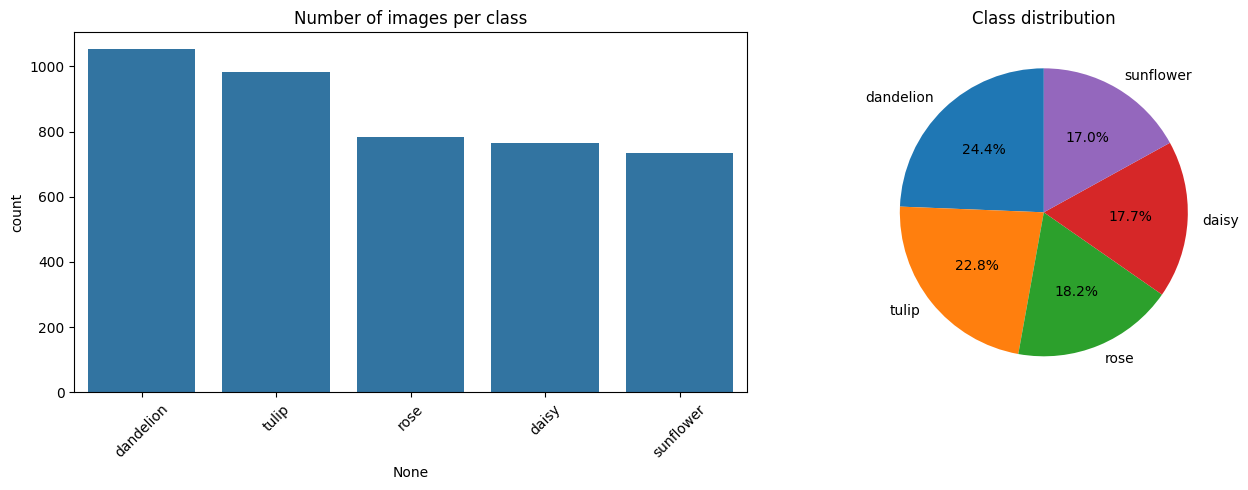

In [3]:
# ── Plot Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=df.index, y=df['count'], ax=axes[0])
axes[0].set_title('Number of images per class')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(df['count'], labels=df.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class distribution')

plt.tight_layout()
plt.savefig('../models/flowers_distribution.png')
plt.show()

In [4]:
# ── ตรวจสอบ Corrupt Images ───────────────────────────────────────
corrupt = []

for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            Image.open(fpath).verify()
        except:
            corrupt.append(fpath)

print(f'รูป Corrupt: {len(corrupt)} ใบ')

# 🔥 ลบแบบ safe
for f in corrupt:
    try:
        os.remove(f)
    except:
        pass

print('ลบแล้ว')

รูป Corrupt: 0 ใบ
ลบแล้ว


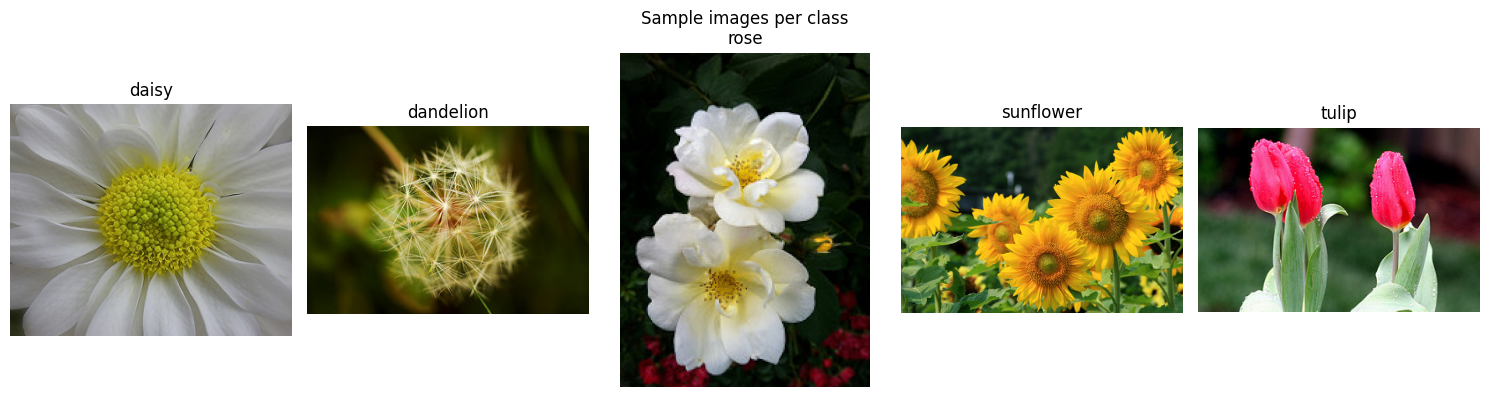

In [5]:
# ── ดูตัวอย่างรูป ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 4))

for ax, cls in zip(axes, CLASSES):
    folder = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    if len(imgs) == 0:
        ax.set_title(f'{cls}\n(no data)')
        ax.axis('off')
        continue

    img = Image.open(os.path.join(folder, imgs[0])).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.suptitle('Sample images per class')
plt.tight_layout()
plt.savefig('../models/flowers_samples.png')
plt.show()

In [6]:
# ── ตรวจสอบขนาดรูป ───────────────────────────────────────────────
widths, heights = [], []

for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    for fname in list(os.listdir(folder))[:20]:
        try:
            img = Image.open(os.path.join(folder, fname))
            widths.append(img.width)
            heights.append(img.height)
        except:
            pass

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

# 🔥 เพิ่ม insight สำคัญ
print('\nInsight:')
print('- รูปมีขนาดไม่เท่ากัน → ต้อง resize (224x224)')
print('- ถ้า class imbalance → โมเดลจะ bias')
print('- Dataset พร้อมสำหรับ CNN / Transfer Learning')

print('\nEDA เสร็จสิ้น — พร้อม train Neural Network')

Width  — min: 171, max: 500, mean: 365
Height — min: 159, max: 400, mean: 270

Insight:
- รูปมีขนาดไม่เท่ากัน → ต้อง resize (224x224)
- ถ้า class imbalance → โมเดลจะ bias
- Dataset พร้อมสำหรับ CNN / Transfer Learning

EDA เสร็จสิ้น — พร้อม train Neural Network
